In [15]:
from datetime import datetime
import pandas as pd
import networkx as nx
from visualize_ean import plot_ean, draw_ean
from build_ean import build_ean, add_headway_arcs, propagate, enrich_trip_data_with_boundaries, propagate2
import headway_integration_copy as hi
import numpy as np
from collections import defaultdict


# Import infrastructure and timetable, clean and prepare data

In [16]:
def reassign_trip_ids_by_departure(trip_data, first_station="ME", second_station="MAL", save_path=None):
    entries_first = []
    entries_second = []
    entries_other = []

    for old_id, stops in trip_data.items():
        if not stops:
            continue
        first_stop = stops[0][0]
        # prefer explicit departure time at index 2, fallback to index 1
        dep_time = None
        if len(stops[0]) > 2 and stops[0][2] is not None:
            dep_time = stops[0][2]
        elif len(stops[0]) > 1:
            dep_time = stops[0][1]
        else:
            dep_time = pd.NaT

        record = (old_id, dep_time)
        if first_stop == first_station:
            entries_first.append(record)
        elif first_stop == second_station:
            entries_second.append(record)
        else:
            entries_other.append(record)

    # sort by departure time (NaT will go last)
    def _sort_key(x): return (pd.Timestamp.max if pd.isna(x[1]) else x[1])
    entries_first.sort(key=_sort_key)
    entries_second.sort(key=_sort_key)
    entries_other.sort(key=_sort_key)

    ordered_old_ids = [r[0] for r in (entries_first + entries_second + entries_other)]

    new_trip_data = {}
    for new_id, old_id in enumerate(ordered_old_ids, start=1):
        new_trip_data[new_id] = trip_data[old_id]

    if save_path:
        np.save(save_path, new_trip_data, allow_pickle=True)

    return new_trip_data, ordered_old_ids

# Example usage:
# new_trip_data, ordered_old_ids = reassign_trip_ids_by_departure(trip_data, "ME", "MAL", save_path="inputs2/trip_data_reassigned.npy")
# selected_trips_sorted = np.array(list(new_trip_data.keys()))

In [17]:
scenario = "1a"

SCENARIOS = {
    "0": {"base", "existing"},
    "1a": {"base", "existing", "dt_me_lag", "dt_tel_pla", "dt_natkomp_sta", "dt_sta_cia", "dt_cold_sblLac", "dt_lasa_oris"},
    "1b": {"base", "existing"},
    "2a": {"base", "existing"},
    "all": None,   # special case
}

ACTIVE_SCENARIO = SCENARIOS[scenario]

def load_network_csv(path, index_col):
    df = pd.read_csv(path, sep=";", decimal=",", index_col=index_col)

    if scenario == "all":
        if "edge_type" in df.columns:
            return df[df["edge_type"] != "connecting"]
        return df

    return df[df["scenario"].fillna("").apply(lambda s: bool(set(map(str.strip, s.split(","))) & ACTIVE_SCENARIO))]

In [18]:
nodesDf = load_network_csv(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\SimulatedAnnealing\network_with_altitude\double_track_network\nodes_double.csv","node_id")
edgesDf = load_network_csv(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\SimulatedAnnealing\network_with_altitude\double_track_network\edges_double.csv","edge_id")
edgesDf["length"] = (edgesDf["node_to"].map(nodesDf["pk_rel"])- edgesDf["node_from"].map(nodesDf["pk_rel"])).abs()
#trip_data = np.load(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\plottingRailML\230215 FBS Fpl 2026-NB-1443983-3.npy", allow_pickle=True).item()
trip_data = np.load(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\plottingRailML\RidottoStamm6.npy", allow_pickle=True).item()
#trip_data = np.load(r"C:\Users\LeoC\VSCodes\optimizationVinschgau\SimulatedAnnealing\MinimumHeadways\retry\data\trip_data_17.npy", allow_pickle=True).item()
headway_dict = np.load(fr"C:\Users\LeoC\VSCodes\optimizationVinschgau\SimulatedAnnealing\Conflicts\all_min_headways{scenario}.npy", allow_pickle=True).item()
selected_trips_sorted = np.array(list(trip_data.keys()))

In [19]:
trip_data = {
    train_id: [
        (station, arr_dt, dep_dt, True)
        for station, arr_dt, dep_dt in stops
    ]
    for train_id, stops in trip_data.items()
}

In [20]:
for t in trip_data:
    print((trip_data[t]))

[('ME', datetime.datetime(1900, 1, 1, 8, 52, 18), datetime.datetime(1900, 1, 1, 8, 52, 18), True), ('LAG', datetime.datetime(1900, 1, 1, 8, 54, 19), datetime.datetime(1900, 1, 1, 8, 55, 7), True), ('MAR', datetime.datetime(1900, 1, 1, 8, 57, 34), datetime.datetime(1900, 1, 1, 9, 0, 18), True), ('TEL', datetime.datetime(1900, 1, 1, 9, 8, 39), datetime.datetime(1900, 1, 1, 9, 12, 18), True), ('RAB', datetime.datetime(1900, 1, 1, 9, 14, 1), datetime.datetime(1900, 1, 1, 9, 14, 49), True), ('PLA', datetime.datetime(1900, 1, 1, 9, 17), datetime.datetime(1900, 1, 1, 9, 17, 48), True), ('NAT', datetime.datetime(1900, 1, 1, 9, 20, 39), datetime.datetime(1900, 1, 1, 9, 22, 8), True), ('STA', datetime.datetime(1900, 1, 1, 9, 25, 1), datetime.datetime(1900, 1, 1, 9, 30, 18), True), ('CIA', datetime.datetime(1900, 1, 1, 9, 33, 3), datetime.datetime(1900, 1, 1, 9, 33, 51), True), ('CAB', datetime.datetime(1900, 1, 1, 9, 37, 20), datetime.datetime(1900, 1, 1, 9, 38, 20), True), ('LAC', datetime.date

In [21]:
trip_data, ordered_old_ids=reassign_trip_ids_by_departure(trip_data)

In [22]:
def get_routing_node(node, direction):
    """
    For trains towards Malles, use station side nodes when available.
    For trains towards Merano, always use main station nodes.
    """

    if direction == "malles":

        side_node = f"{node}_side"

        if side_node in nodesDf.index:
            return side_node

    return node


# --------------------------------------------------
# Route builder
# --------------------------------------------------

def build_route(nodesDf, edgesDf, start, end):
    successors = defaultdict(list)

    for _, edge in edgesDf.iterrows():
        successors[edge["node_from"]].append(edge["node_to"])
        successors[edge["node_to"]].append(edge["node_from"])
    direction = ("malles" if nodesDf.loc[start, "pk_rel"] <= nodesDf.loc[end, "pk_rel"] else "merano")

    route_start = get_routing_node(start, direction)
    route_end = get_routing_node(end, direction)

    route = [route_start]

    current = route_start
    visited = {route_start}

    while current != route_end:

        pk_current = nodesDf.loc[current, "pk_rel"]

        # only move towards destination
        candidates = [
            n for n in successors[current]
            if (
                nodesDf.loc[n, "pk_rel"] > pk_current
                if direction == "malles"
                else nodesDf.loc[n, "pk_rel"] < pk_current
            )
        ]

        if not candidates:
            raise ValueError(
                f"No valid successor from {current} towards {route_end}"
            )

        # at branching points choose preferred track
        if len(candidates) > 1:

            preferred = [
                n for n in candidates
                if (
                    nodesDf.loc[n, "y"] != 0
                    if direction == "malles"
                    else nodesDf.loc[n, "y"] == 0
                )
            ]

            if preferred:
                candidates = preferred

        next_node = candidates[0]

        if next_node in visited:
            raise ValueError(
                f"Loop detected: {current} -> {next_node}"
            )

        route.append(next_node)
        visited.add(next_node)

        current = next_node

    return route


# --------------------------------------------------
# Build routing dictionary
# --------------------------------------------------

routing_results = {}

for stop_col in ["stop_slow", "stop_fast"]:

    stops = nodesDf.index[(nodesDf[stop_col] == 1) & (nodesDf["y"] == 0)].tolist()

    for start, end in zip(stops[:-1], stops[1:]):

        routing_results[(start, end)] = build_route(nodesDf, edgesDf, start, end)
        routing_results[(end, start)] = build_route(nodesDf, edgesDf, end, start)

In [23]:
routes = {}
for trip_id, trip in trip_data.items():
    start, end = trip[0][0], trip[-1][0]
    routes[trip_id] = build_route(nodesDf, edgesDf, start, end)

In [24]:
from copy import deepcopy

def add_side_nodes_to_trip_data(trip_data, nodesDf):
    """
    Return a copy of trip_data where terminal nodes are replaced by their
    '_side' counterpart, but only for trains running from Merano to Malles
    (i.e. decreasing pk_rel).

    A stop 'X' is replaced by 'X_side' only if:
      - 'X_side' exists in nodesDf, and
      - the train direction is Merano -> Malles.
    """
    trip_data_sides = deepcopy(trip_data)

    available_nodes = set(nodesDf.index)

    for train_id, stops in trip_data_sides.items():

        # Need at least two stops to infer direction
        if len(stops) < 2:
            continue

        pk0 = nodesDf.loc[stops[0][0], "pk_rel"]
        pk1 = nodesDf.loc[stops[1][0], "pk_rel"]

        # Merano -> Malles corresponds to decreasing pk_rel
        merano_to_malles = pk1 > pk0

        if not merano_to_malles:
            continue

        for i, (node, arr, dep, is_stop) in enumerate(stops):

            side_node = f"{node}_side"

            if side_node in available_nodes:
                stops[i] = (side_node, arr, dep, True)

    return trip_data_sides

In [25]:
trip_data_sides = add_side_nodes_to_trip_data(trip_data, nodesDf)

In [26]:
IG = hi.build_infra_graph(edgesDf)
chains, boundary_nodes = hi.extract_chains(IG, nodesDf)

print("Chains:", chains)
print("Boundary Nodes:", boundary_nodes)
trip_data_enriched = enrich_trip_data_with_boundaries(trip_data_sides, routes, nodesDf, boundary_nodes)

Chains: {('Dev_01_PLA', 'Dev_PL11_02'): ['Dev_01_PLA', 'Pa_PLA_31', 'PLA', 'Pa_PLA_32', 'PL09', 'Pr_I_PLA_52', 'Pr_E_PLA_02', 'HD_303_02', 'HD_303_04', 'km48500', 'Pr_E_NAT_01', 'Pr_I_NAT_51', 'PL10', 'Pa_NAT_31', 'NAT', 'Pa_NAT_32', 'Pr_E_NAT_02', 'Pr_E_PL11_01', 'Pr_I_PL11_51', 'PL11', 'Pr_I_PL11_52', 'Dev_PL11_02'], ('Dev_PL11_02', 'Dev_STA_02'): ['Dev_PL11_02', 'Pr_E_PL11_02_side', 'SblNatKomp_side', 'Pr_E_STA_01_side', 'Pa_E_STA_61_side', 'Pr_I_STA_51_side', 'Dev_STA_01_side', 'Pa_I_STA_31_side', 'STA_side', 'Pa_I_STA_32_side', 'Dev_STA_02'], ('Dev_ORIS_01', 'Dev_SPON_01'): ['Dev_ORIS_01', 'Pr_I_ORIS_71', 'PL30', 'Pa_ORIS_31', 'ORIS', 'Pa_ORIS_32', 'Pr_E_ORIS_02', 'HD_702_02', 'Pr_E_SPON_01', 'Pa_E_SPON_81', 'Pr_I_SPON_71', 'PL31', 'Pr_I_SPON_51', 'Pa_I_SPON_61', 'Dev_SPON_01'], ('Dev_SPON_01', 'Dev_SPON_02'): ['Dev_SPON_01', 'Pa_I_SPON_31_side', 'SPON_side', 'Pa_I_SPON_32_side', 'Dev_SPON_02'], ('Dev_MAR_01', 'Dev_MAR_02'): ['Dev_MAR_01', 'Pa_I_MAR_31_side', 'MAR_side', 'Pa_I_MAR

In [27]:
# Remove opposite-direction headways on double-track chains
headway_dict = deepcopy(headway_dict)

# --------------------------------------------------
# Step 1: Count how many infrastructure edges occupy
# each elementary pk interval
# --------------------------------------------------

pk_values = sorted(nodesDf["pk_rel"].unique())

interval_count = defaultdict(int)

for _, edge in edgesDf.iterrows():

    pk1 = nodesDf.loc[edge["node_from"], "pk_rel"]
    pk2 = nodesDf.loc[edge["node_to"], "pk_rel"]

    a, b = sorted((pk1, pk2))

    for left, right in zip(pk_values[:-1], pk_values[1:]):
        if left >= a and right <= b:
            interval_count[(left, right)] += 1


# --------------------------------------------------
# Step 2: Determine whether each chain is entirely
# on double track
# --------------------------------------------------

double_track_chains = set()

for chain_key, chain_nodes in chains.items():

    is_double = True

    for n1, n2 in zip(chain_nodes[:-1], chain_nodes[1:]):

        pk1 = nodesDf.loc[n1, "pk_rel"]
        pk2 = nodesDf.loc[n2, "pk_rel"]

        a, b = sorted((pk1, pk2))

        for left, right in zip(pk_values[:-1], pk_values[1:]):
            if left >= a and right <= b:
                if interval_count[(left, right)] < 2:
                    is_double = False
                    break

        if not is_double:
            break

    if is_double:
        double_track_chains.add(chain_key)


# --------------------------------------------------
# Step 3: Remove opposite-direction headways
# on double-track chains
# --------------------------------------------------

for key in list(headway_dict):

    chain_key, cat1, cat2 = key

    if chain_key in double_track_chains:

        opposite = (
            ("up" in cat1 and "down" in cat2)
            or
            ("down" in cat1 and "up" in cat2)
        )

        if opposite:
            del headway_dict[key]

# Build EAN, add headway constraints

In [28]:
constraints, skipped = hi.assemble_headway_constraints(trip_data_sides, trip_data_enriched, routes, nodesDf, chains, headway_dict)
print("Constraints:", constraints)
print("Skipped:", skipped)

G_scheduled = build_ean(trip_data_enriched)
G_scheduled = add_headway_arcs(G_scheduled, constraints)
assert nx.is_directed_acyclic_graph(G_scheduled), "graph must stay a DAG"

[assemble_headway_constraints] 89 entries skipped -- inspect `skipped` for details (unmatched chains/categories).
Constraints: [{'train_i': 10, 'seq_i': 15, 'event_i': 'dep', 'train_j': 11, 'seq_j': 20, 'event_j': 'dep', 'min_headway': 106.68367073946143, 'resource': ('Dev_PL13_01', 'Dev_PL15_01')}, {'train_i': 1, 'seq_i': 3, 'event_i': 'dep', 'train_j': 2, 'seq_j': 2, 'event_j': 'dep', 'min_headway': 197.19135547920254, 'resource': ('Dev_MAR_01', 'Dev_MAR_02')}, {'train_i': 2, 'seq_i': 2, 'event_i': 'dep', 'train_j': 3, 'seq_j': 3, 'event_j': 'dep', 'min_headway': 116.89006458594898, 'resource': ('Dev_MAR_01', 'Dev_MAR_02')}, {'train_i': 8, 'seq_i': 32, 'event_i': 'dep', 'train_j': 9, 'seq_j': 32, 'event_j': 'dep', 'min_headway': 197.99315544883314, 'resource': ('Dev_MAR_01', 'Dev_MAR_02')}, {'train_i': 9, 'seq_i': 32, 'event_i': 'dep', 'train_j': 10, 'seq_j': 22, 'event_j': 'dep', 'min_headway': 198.01427030987355, 'resource': ('Dev_MAR_01', 'Dev_MAR_02')}, {'train_i': 4, 'seq_i': 2,

# Stochastic Perturbation

In [29]:
node_perturbations, edge_perturbations = hi.generate_perturbation_scenarios(G_scheduled,
    n_scenarios=3,
    entry_delay_mean=5*60,
    entry_delay_std=2*60,
    running_delay_mean=0*60,
    running_delay_std=1*60,
    seed=42,
)

## Propagation

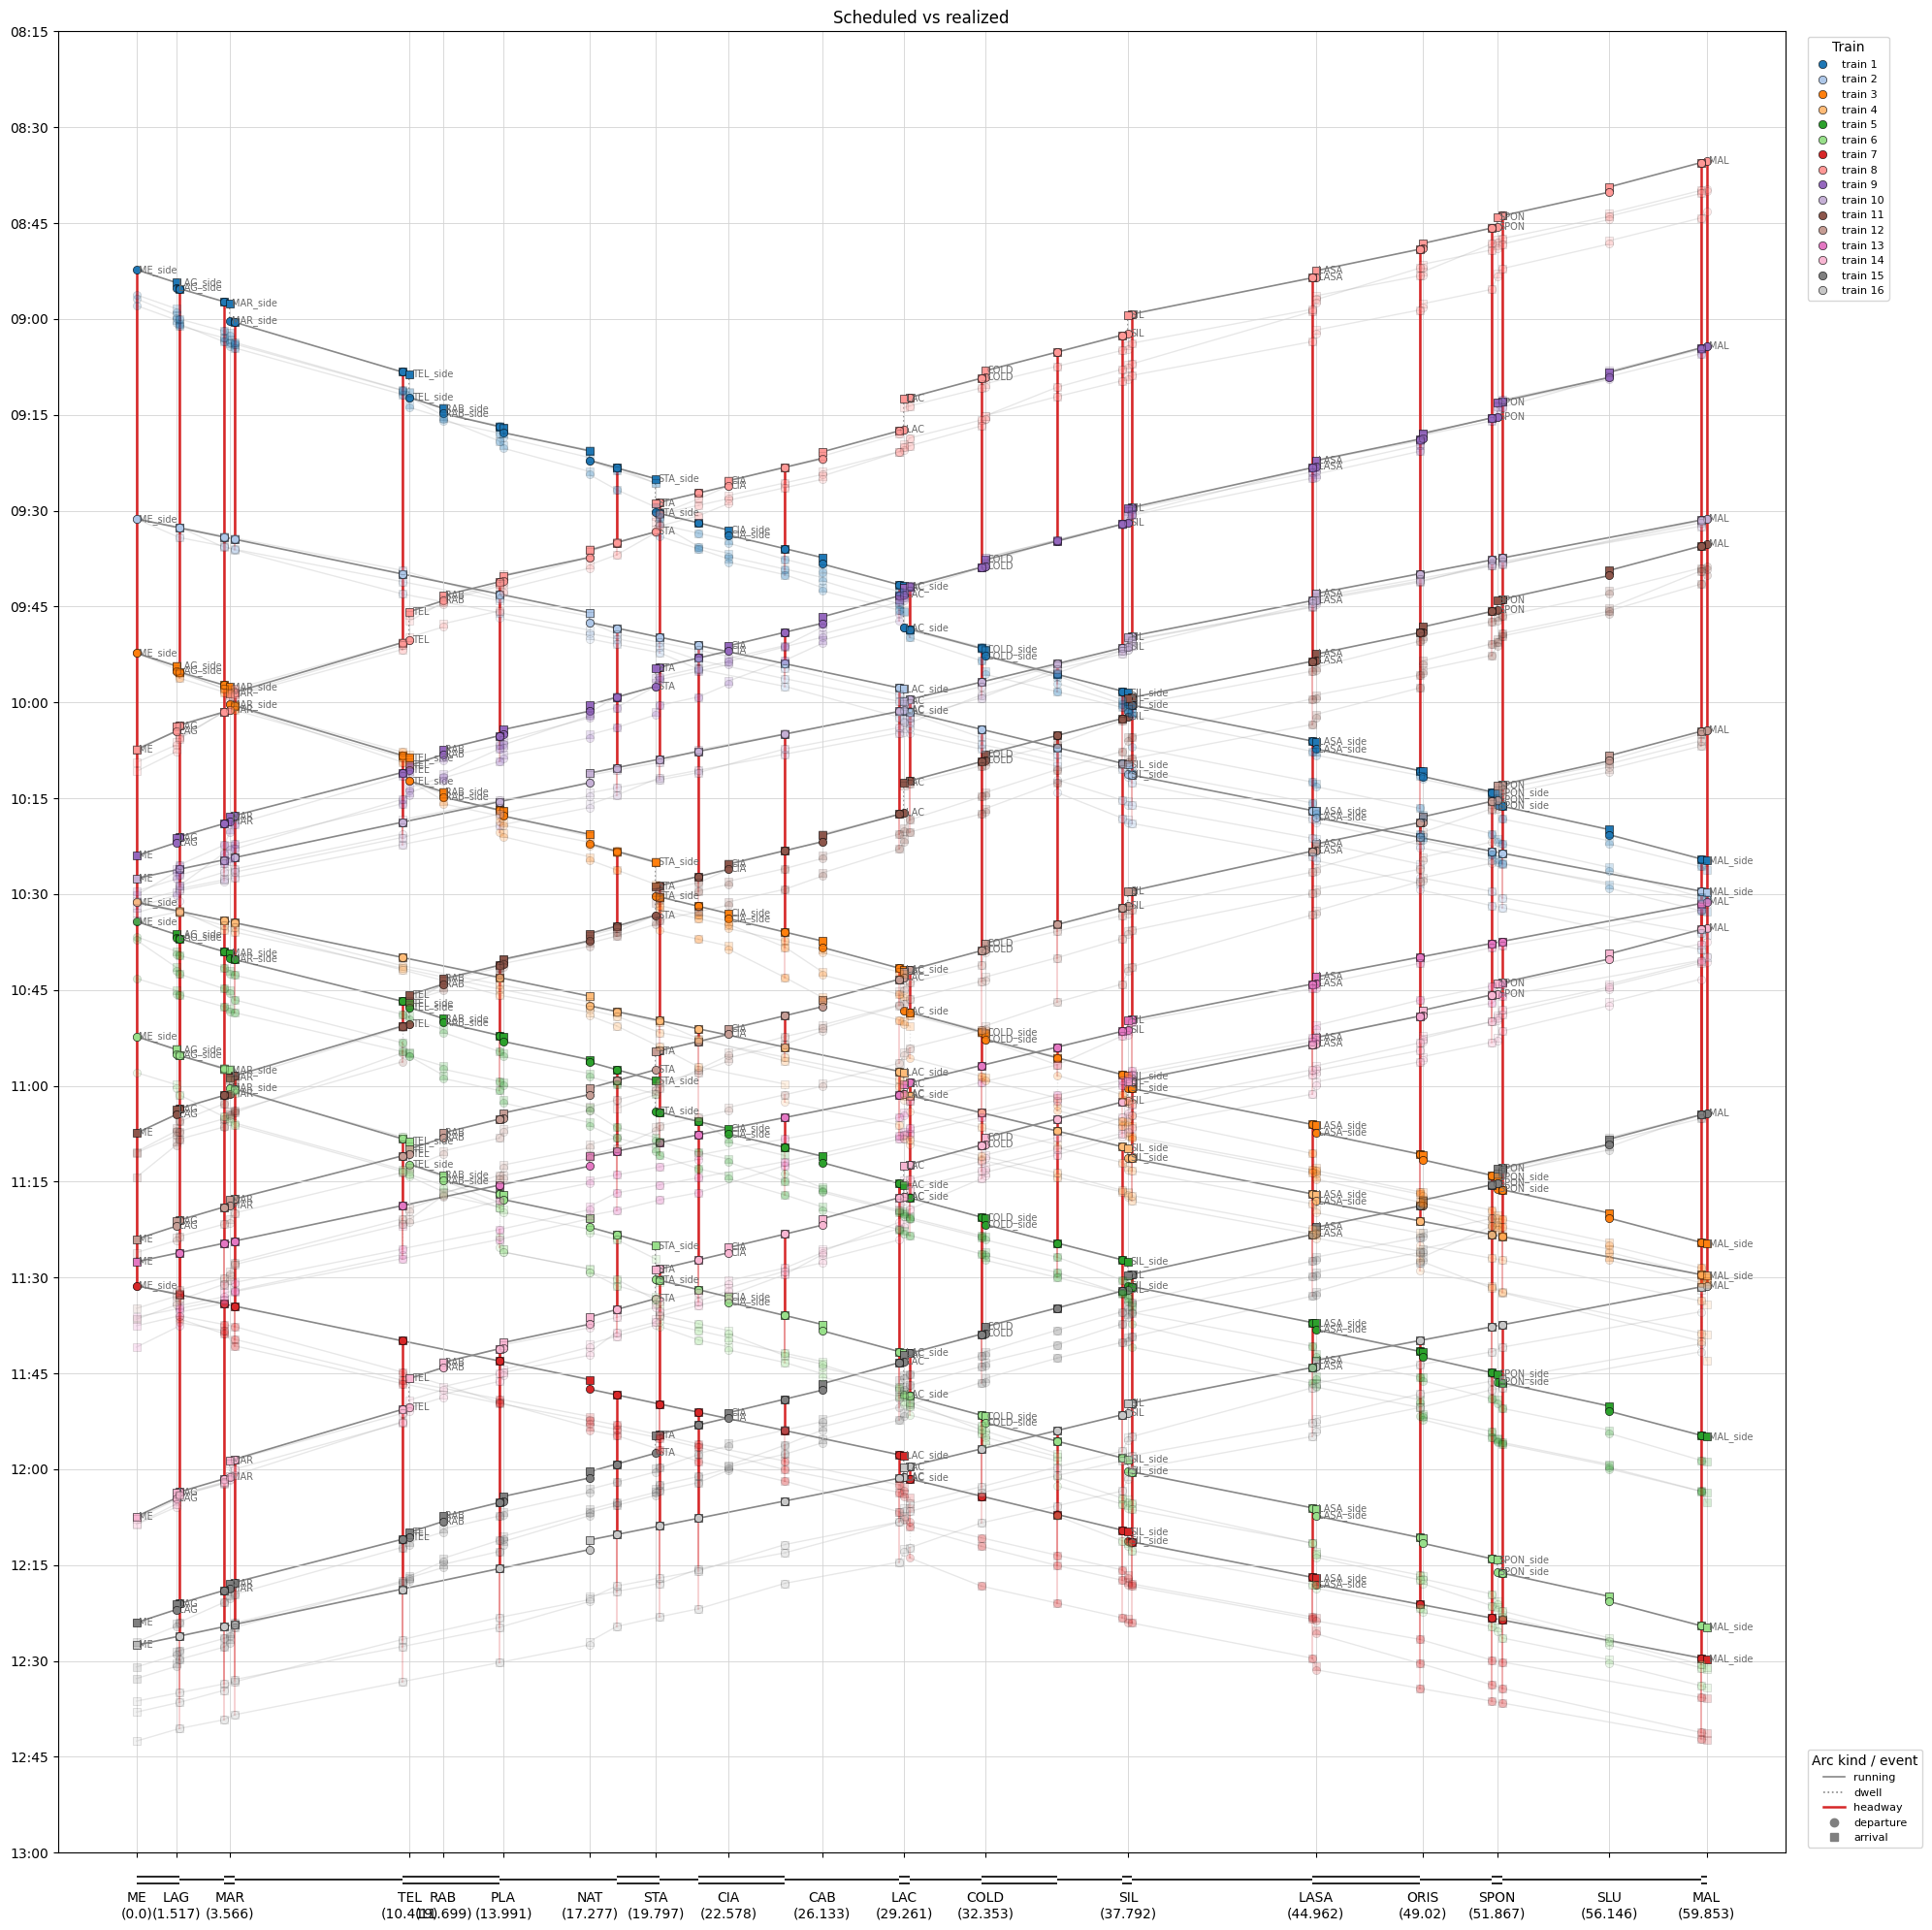

In [30]:
realized_graphs = []

for node_p, edge_p in zip(node_perturbations, edge_perturbations):

    G_realized = propagate2(
        G_scheduled,
        edge_perturbations=edge_p,
        node_perturbations=node_p,
    )

    realized_graphs.append(G_realized)


fig, ax = plot_ean(G_scheduled,nodesDf,edgesDf,title="Scheduled vs realized")

for G_realized in realized_graphs:
    draw_ean(G_realized,nodesDf,ax,alpha=0.2,linewidth_scale=0.8,)

## Report

In [31]:
def compute_train_durations(G):
    """
    Returns
    -------
    dict
        {train_id: duration (timedelta)}
    """
    durations = {}
    trains = sorted({data["train"] for _, data in G.nodes(data=True) if "train" in data})

    for train in trains:
        events = [data for _, data in G.nodes(data=True) if data.get("train") == train]
        dep = min(e["time"] for e in events if e["event"] == "dep")
        arr = max(e["time"] for e in events if e["event"] == "arr")
        durations[train] = arr - dep
        
    return durations

In [32]:
def compare_to_schedule(G_scheduled, G_realized):
    scheduled = compute_train_durations(G_scheduled)
    realized = compute_train_durations(G_realized)
    report = {}
    for train in scheduled:
        report[train] = {"scheduled": scheduled[train], "realized": realized[train], "extra_time": realized[train] - scheduled[train]}
    return report

In [33]:
# Arrival delay at destination station
arrival_report = compare_to_schedule(G_scheduled, G_realized)

for i, (node_perturbation, edge_perturbation, G_realized) in enumerate(
    zip(node_perturbations, edge_perturbations, realized_graphs)
):

    arrival_report = compare_to_schedule(G_scheduled, G_realized)

    # Initial departure delays per train
    departure_delay = defaultdict(float)

    for node, delay in node_perturbation.items():
        train = G_scheduled.nodes[node]["train"]
        departure_delay[train] += delay

    # Sum of imposed running-time extensions per train
    running_delay = defaultdict(float)

    for (u, v), delay in edge_perturbation.items():
        train = G_scheduled.nodes[u]["train"]
        running_delay[train] += delay

    total_dep = 0
    total_run = 0
    total_sec = 0

    print(f"\nScenario {i}")
    print("-" * 70)

    for train in sorted(arrival_report):

        dep = departure_delay[train]
        run = running_delay[train]
        sec = arrival_report[train]["extra_time"]

        total_dep += dep
        total_run += run
        total_sec += sec

        print(
            f"Train {train:>2}: "
            f"departure={dep:6.0f}s   "
            f"running={run:6.0f}s   "
            f"arrival delay={sec:6.0f}s"
        )

    n = len(arrival_report)

    print("\nTotals")
    print(f"  Initial departure delays : {total_dep:.0f} s")
    print(f"  Running-time extensions  : {total_run:.0f} s")
    print(f"  Arrival delays           : {total_sec:.0f} s")

    print("\nAverage per train")
    print(f"  Initial departure delays : {total_dep/n:.1f} s")
    print(f"  Running-time extensions  : {total_run/n:.1f} s")
    print(f"  Arrival delays           : {total_sec/n:.1f} s")


Scenario 0
----------------------------------------------------------------------
Train  1: departure=   337s   running=   802s   arrival delay=    22s
Train  2: departure=   175s   running=   424s   arrival delay=   403s
Train  3: departure=   390s   running=   432s   arrival delay=   310s
Train  4: departure=   413s   running=   778s   arrival delay=   797s
Train  5: departure=    66s   running=   676s   arrival delay=   475s
Train  6: departure=   144s   running=   848s   arrival delay=   562s
Train  7: departure=   315s   running=   572s   arrival delay=   755s
Train  8: departure=   262s   running=  1008s   arrival delay=   -58s
Train  9: departure=   298s   running=   937s   arrival delay=   370s
Train 10: departure=   198s   running=   604s   arrival delay=   215s
Train 11: departure=   406s   running=  1055s   arrival delay=  -113s
Train 12: departure=   393s   running=   710s   arrival delay=   126s
Train 13: departure=   308s   running=   548s   arrival delay=   519s
Train 1

# Manual Perturbation

## Propagation

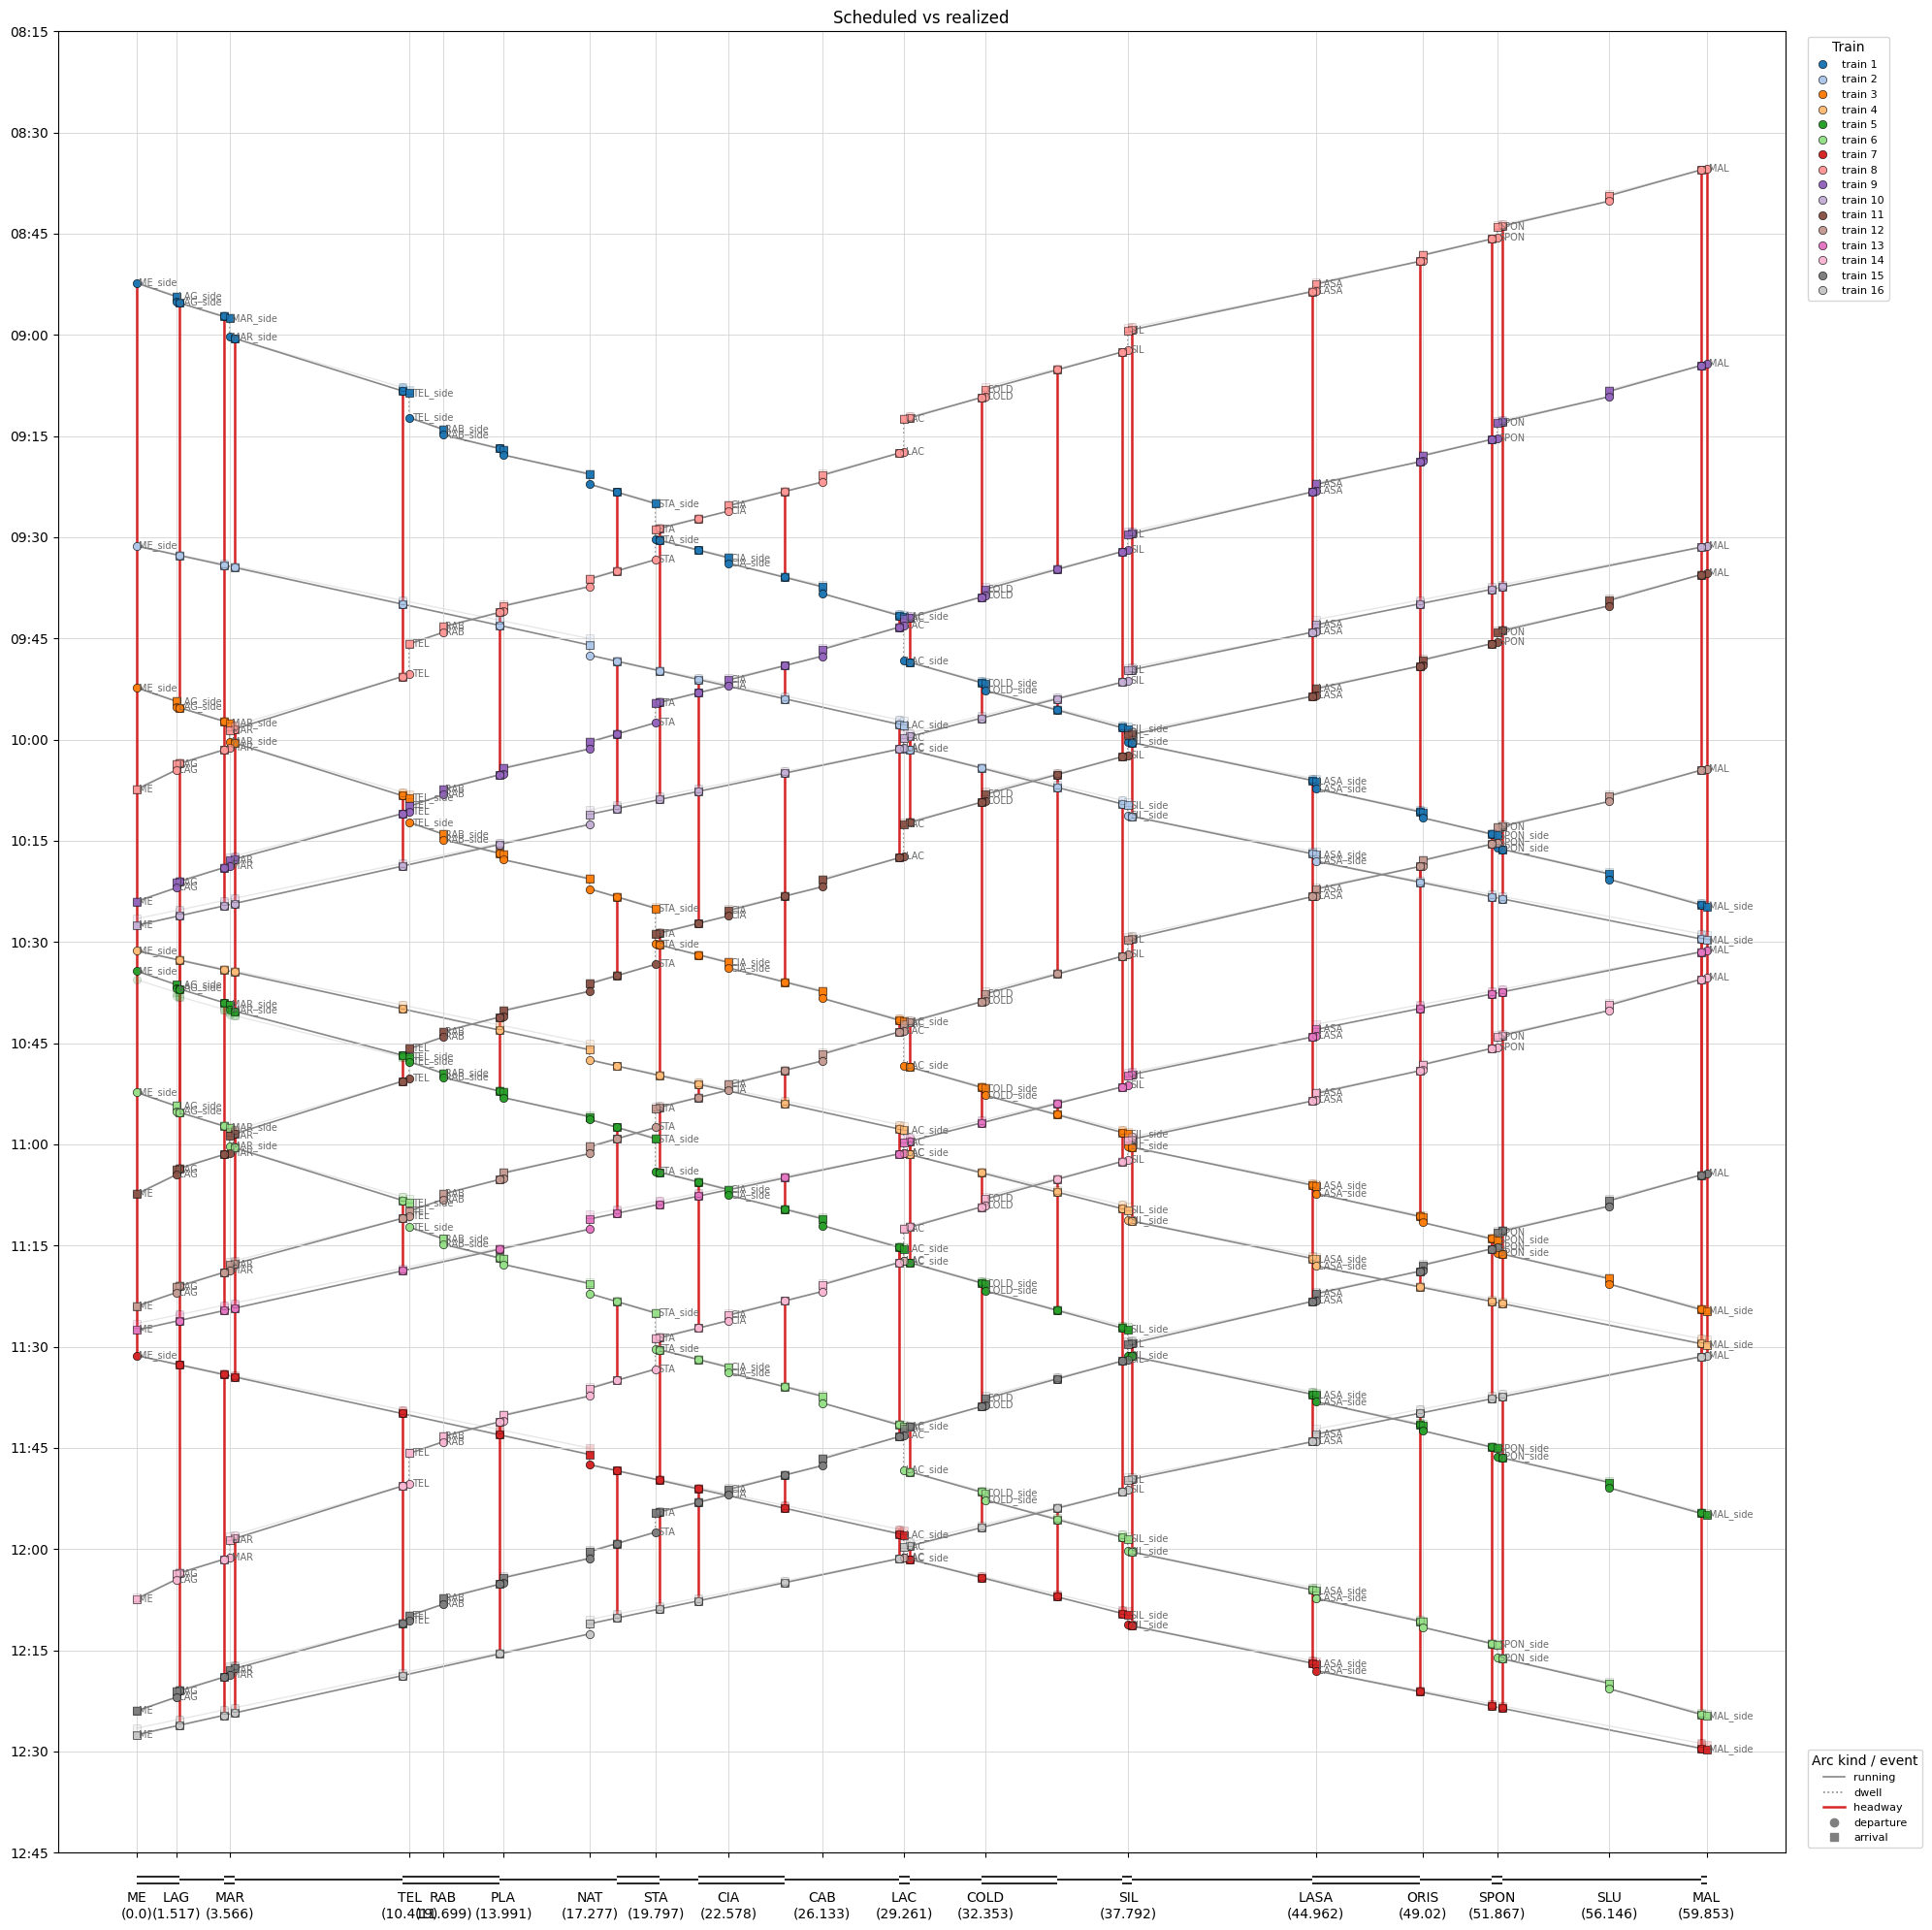

In [34]:
#inject delays manually
running_edges = [(u, v) for u, v, data in G_scheduled.edges(data=True) if data["kind"] == "running"]
edge = running_edges[0]  

#perturbations = [{},{edge: 60},{edge: 120},{edge: 300}]
perturbations = [{edge:0}]


realized_graphs = []

for p in perturbations:

    G_realized = propagate(G_scheduled, p)

    realized_graphs.append(G_realized)


fig, ax = plot_ean(G_scheduled, nodesDf, edgesDf, title="Scheduled vs realized")

for G_realized in realized_graphs:
    draw_ean(G_realized,nodesDf,ax,alpha=0.2,linewidth_scale=0.8,)

## Report

In [35]:
scheduled = compute_train_durations(G_scheduled)

for i, (perturbation, G_realized) in enumerate(zip(perturbations, realized_graphs)):
    realized = compute_train_durations(G_realized)
    primary = sum(perturbation.values()) if perturbation else 0
    print(f"\nPerturbation {i}  (primary delay = {primary:.0f} s)")
    print("-" * 45)
    secondary = 0
    for train in sorted(scheduled):
        extra = realized[train] - scheduled[train]
        # primary delay belongs to the perturbed train only
        propagated = extra - primary if train == 1 else extra
        secondary += max(0, propagated)
        print(
            f"Train {train:>2}: "
            f"scheduled={scheduled[train]:6.0f}s  "
            f"realized={realized[train]:6.0f}s  "
            f"Δ={extra:5.0f}s"
        )

    avg_pri = primary/len(realized)
    avg_sec = secondary/len(realized)
    
    print(f"\n Total primary delay   : {primary:.0f} s")
    print(f"Total secondary delay : {secondary:.0f} s")
    print(f"\n Average primary delay   : {avg_pri:.0f} s")
    print(f"Average secondary delay   : {avg_sec:.0f} s")


Perturbation 0  (primary delay = 0 s)
---------------------------------------------
Train  1: scheduled=  5546s  realized=  5530s  Δ=  -16s
Train  2: scheduled=  3505s  realized=  3459s  Δ=  -46s
Train  3: scheduled=  5546s  realized=  5530s  Δ=  -16s
Train  4: scheduled=  3505s  realized=  3459s  Δ=  -46s
Train  5: scheduled=  4838s  realized=  4746s  Δ=  -92s
Train  6: scheduled=  5546s  realized=  5530s  Δ=  -16s
Train  7: scheduled=  3505s  realized=  3459s  Δ=  -46s
Train  8: scheduled=  5526s  realized=  5515s  Δ=  -11s
Train  9: scheduled=  4782s  realized=  4774s  Δ=   -8s
Train 10: scheduled=  3374s  realized=  3315s  Δ=  -59s
Train 11: scheduled=  5526s  realized=  5515s  Δ=  -11s
Train 12: scheduled=  4782s  realized=  4774s  Δ=   -8s
Train 13: scheduled=  3374s  realized=  3315s  Δ=  -59s
Train 14: scheduled=  5526s  realized=  5515s  Δ=  -11s
Train 15: scheduled=  4782s  realized=  4774s  Δ=   -8s
Train 16: scheduled=  3374s  realized=  3315s  Δ=  -59s

 Total primary del